In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
from statsmodels.tsa.holtwinters import ExponentialSmoothing as ES 


In [2]:
df = pd.read_csv('Auto_sales.csv', sep=';', \
    decimal=',', parse_dates=['Date'], \
    index_col='Date')
df = df.dropna()

In [3]:
h=5

In [4]:
des_auto = ES(df.iloc[:-h,:].Auto_sales,trend='add').fit()

c:\Users\mrosk\.conda\envs\ml311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [5]:
print(des_auto.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:               Auto_sales   No. Observations:                  239
Model:             ExponentialSmoothing   SSE                        1454134.804
Optimized:                         True   AIC                           2090.516
Trend:                         Additive   BIC                           2104.422
Seasonal:                          None   AICC                          2090.879
Seasonal Periods:                  None   Date:                 Mon, 21 Oct 2024
Box-Cox:                          False   Time:                         11:21:15
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.5430358                alpha                 True
smoothing_trend            0.01963

In [6]:
df['des_fit'] = des_auto.fittedvalues

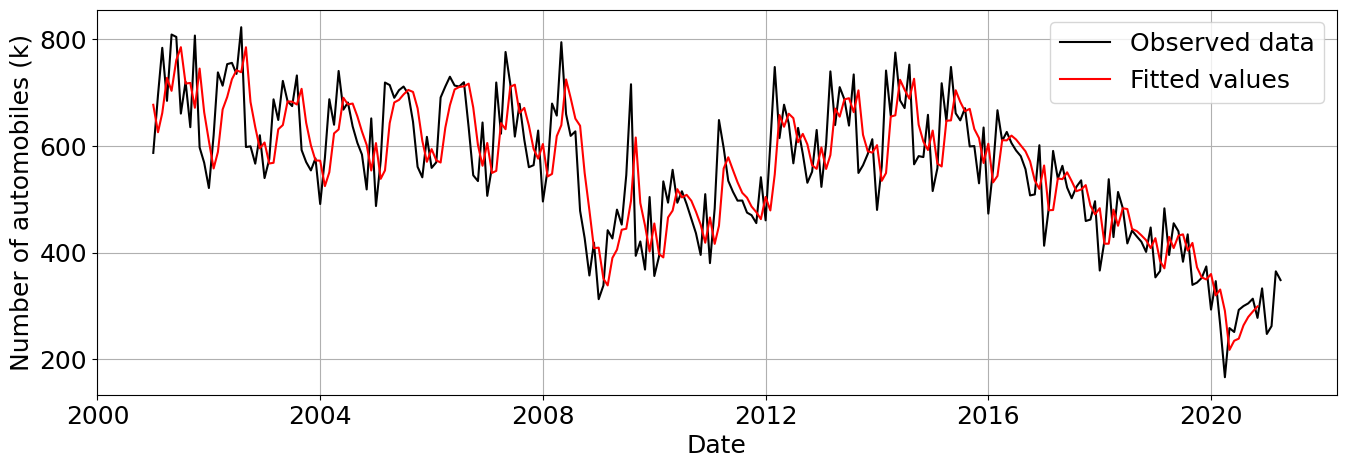

In [7]:
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(16, 5), dpi=100)

# observed data
plt.plot(df.index, df.Auto_sales, \
    color='k', label='Observed data')

# DES model
plt.plot(df.index, df.des_fit, \
    color='r', label='Fitted values')

# set artists
plt.gca().set(xlabel='Date', \
    ylabel='Number of automobiles (k)')
plt.legend()
plt.grid()
plt.show()

In [8]:
df.des_fit.iloc[-h:] = des_auto.forecast(steps=h)

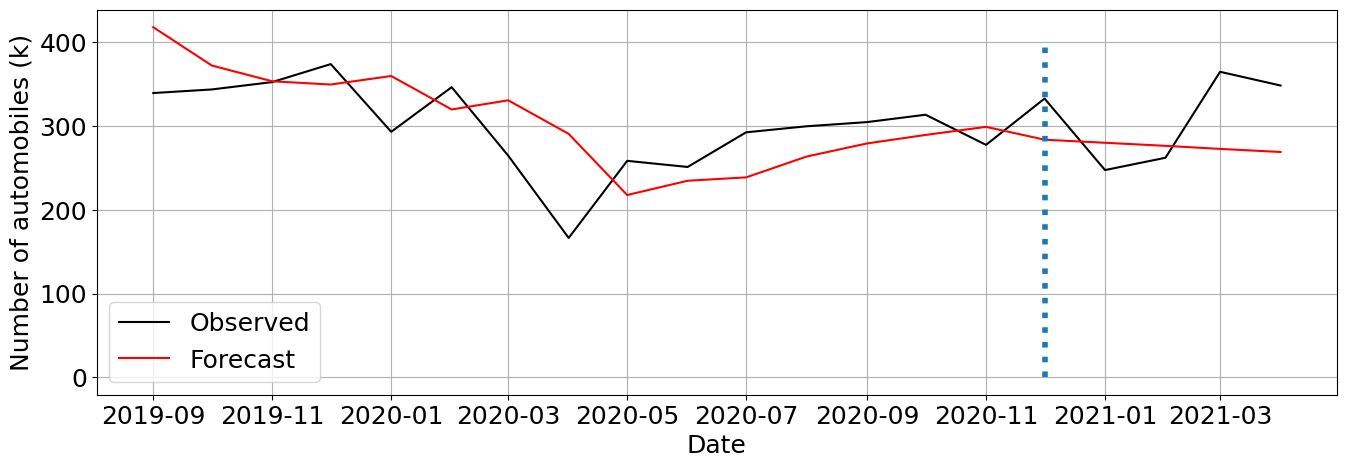

In [9]:
plt.figure(figsize=(16, 5), dpi=100)

# last 20 observations
plt.plot(df.Auto_sales[-20:], \
    color='k', label='Observed')

# DES forecasts
plt.plot(df.des_fit[-20:], \
    color='r', label='Forecast')

# indicate forcasting start point
plt.vlines(df.index[-h], 0, 400, \
    linestyles='dotted', lw=4)

# set artists
plt.gca().set(xlabel='Date', \
    ylabel='Number of automobiles (k)')
plt.grid()
plt.legend()
plt.show()


In [10]:
des_damp = ES(df.iloc[:-h,:].Auto_sales, trend='add', damped_trend=True).fit(damping_trend=0.7)

c:\Users\mrosk\.conda\envs\ml311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [11]:
print(des_damp.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:               Auto_sales   No. Observations:                  239
Model:             ExponentialSmoothing   SSE                        1422095.585
Optimized:                         True   AIC                           2087.192
Trend:                         Additive   BIC                           2104.574
Seasonal:                          None   AICC                          2087.677
Seasonal Periods:                  None   Date:                 Mon, 21 Oct 2024
Box-Cox:                          False   Time:                         11:25:59
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.5456358                alpha                 True
smoothing_trend            0.00382

In [12]:
df['des_damp_fit'] = des_damp.fittedvalues

In [13]:
df.des_damp_fit.iloc[-h:] = des_damp.forecast(steps=h)

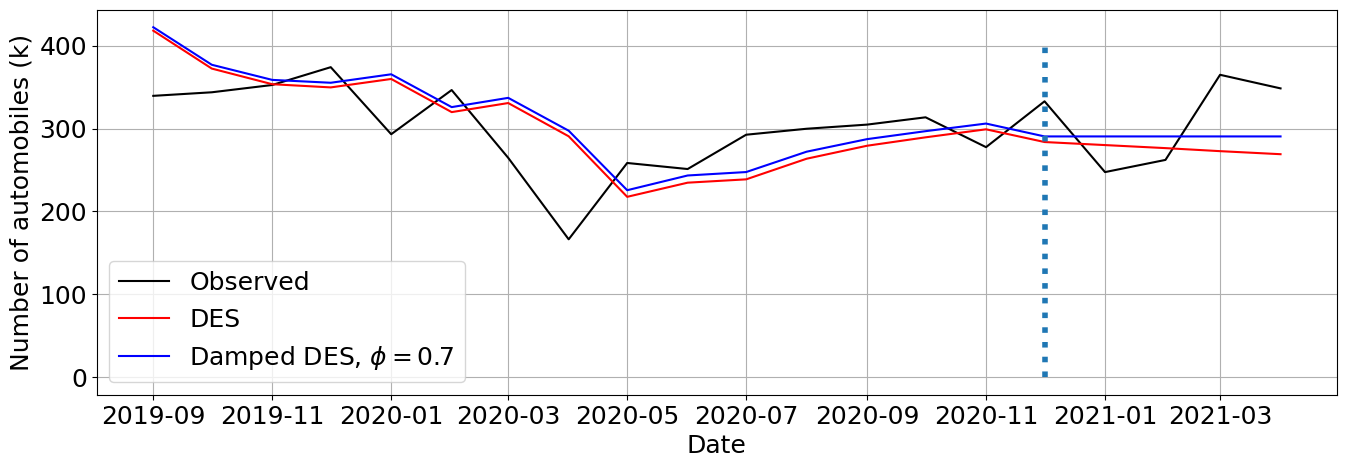

In [14]:
plt.figure(figsize=(16, 5), dpi=100)

# last 20 observations
plt.plot(df.Auto_sales[-20:], \
    color='k', label='Observed')

# DES forecasts
plt.plot(df.des_fit[-20:], \
    color='r', label='DES')

# DES damped forecasts
plt.plot(df.des_damp_fit[-20:], \
    color='b', label='Damped DES, $\phi=0.7$')

# indicate forcasting start point
plt.vlines(df.index[-h], 0, 400, \
    linestyles='dotted', lw=4)

# set artists
plt.gca().set(xlabel='Date', \
    ylabel='Number of automobiles (k)')
plt.grid()
plt.legend()
plt.show()